# Carl von Ossietzky Universität Oldenburg - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [7]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS inst_name,
                        'Carl von Ossietzky Universität Oldenburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              99, -- 'Carl von Ossietzky Universität Oldenburg'
                              445, -- 'Evangelisches Krankenhaus Oldenburg'
                              6612, -- 'UMO - Universitätsmedizin Oldenburg'
                              316, -- 'Klinikum Oldenburg gGmbH'
                              315, -- 'Pius-Hospital Oldenburg'
                              5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                              4564 -- Institute for Science Networking Oldenburg GmbH
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [8]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Carl von Ossietzky Universität Oldenburg,"University of Oldenburg,Dept. of Business Info...",https://openalex.org/W4404294991
1,not assigned,Carl von Ossietzky Universität Oldenburg,"Department of Health Services Research, School...",https://openalex.org/W4401926132
2,Universitätsmedizin Oldenburg,Carl von Ossietzky Universität Oldenburg,"Intensive Care, Emergency Medicine, and Pain T...",https://openalex.org/W4396805765
3,not assigned,Carl von Ossietzky Universität Oldenburg,"Department of Health Services Research, School...",https://openalex.org/W4404252641
4,not assigned,Carl von Ossietzky Universität Oldenburg,"Laboratory of Experimental Ophthalmology, Depa...",https://openalex.org/W4404144355


In [66]:
oal.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [794]:
MAPPING_DICT = {
    'Bibliotheks- und Informationssystem (BIS)': ['informationssystem'],
    'Center für lebenslanges Lernen (C3L)': ['lifelong learning', 'center für lebenslanges lernen'],
    #'CMC - Center for Migration, Education and Cultural Studies': [],
    'COAST - Zentrum für Umwelt- und Nachhaltigkeitsforschung': ['sustainability research', 'coast-zentrum'],
    #'ecco-ecology + communication Unternehmensberatung GmbH': [],
    'Fakultät I - Bildungs- und Sozialwissenschaften': ['(department|institute) (for|of) social science', '(school|institute|faculty|department) of education(al)?', 
                                                        'educational science', 'special (education|needs)', 'lernforschung',
                                                        'rehabilitation', 'research on learning', 'pedagogy', 'schooling', 
                                                        '(open|political|continuing) (education|theory)', 'department i educational',
                                                        'sozialwissenschaft(liche|en)', 'päd(a)?gogik', 'social sciences institute'
                                                       ],
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': ['(business|energy) (informati(on|cs)|application|administration)', 
                                                                        'applied artific(i)?al intelligence', 'information technology',
                                                                        'digitalized', '(department|fachbereich|media)( of| für)? (economics|informati(k|cs)|business)', 
                                                                        'comput(er|ing) science', 'offis', 'sustainable information', 'economic(s and)? law', 
                                                                        'resilience learning', 'vwl', 'marketing', 'safety-security',
                                                                        'interconnected systems', '(public|ecological) economics', 'wirtschaftspädagogik', 'micro(-)?robotics',
                                                                        'rechtswissenschaften', 'finance and banking', 'medieninformatik', 
                                                                        'software engineering', 'accounting', 'innovation', 'formale sprachen', 
                                                                        'informatics (department|education)', 'embedded hardware', 'computational intelligence', 
                                                                        'safety and explainability', 'betriebswirtschaft'
                                                                       ],
    'Fakultät III - Sprach- und Kulturwissenschaften': ['sport(s)? science', '(institut(e)?|department) (of|für) musi(k|c)', 'kulturwissenschaften',
                                                        'department of (german|dutch)', 'visuelle kultur', '(german|american|slavic|dutch) studies',
                                                        'musicology', 'linguistics', '(niederland|slaw|german)istik', 'slavic department', 'speech and music lab'
                                                       ],
    'Fakultät IV - Human- und Gesellschaftswissenschaften': ['philosoph(ie|y)', 'department of history', 'religionspädagogik', 'institut für geschichte',
                                                             'so(z|c)iolog(ie|y)', 'historisches institut', 'school iv', 'institute of history',
                                                             'theolog(ie|y)', 'sportwissenschaft', 'fak. iv'
                                                            ],
    'Fakultät V - Mathematik und Naturwissenschaften': ['(icbm)', 'chemi(e|stry) (und|and) biolog(ie|y)', 'industrial chemistry',
                                                        '(ins(t)?(i)?tut(e)?|department|school) (of|f(ü|u|ue)?r|at|for) (ch(e)?mi(e|stry)|physi(k|cs)|biolog(ie|y))', 
                                                        'biodiversit', 'animal navigation', 'biologie Und umweltwissenschaften',
                                                        '(environmental|natural) science', 'nanoscale', 'mathemati(k|cs|sches)', '(geo|bio)(chemistry|diversity)', 
                                                        'dida(k|c)ti(k|cs) (der|of) (chemi(e|stry)|physi(k|cs))',
                                                        '(physics|chemistry) department', 'sustainable energy', '(landscape|aquatic) ecology', 'geology', 
                                                        '(angewandte|technische|applied|physical|theoretical|organische|marine) chemi(e|stry)', 
                                                        'chemical engineering', 'ecology of plants', 'theoretical physic', 'gewässerökologie',
                                                        'evolutionsbiologie', 'marine sensor(ik|s)', 'genomics', 'evolutionary biology', '(plant|functional) ecology',
                                                        '(chemistry|physics) education', 'soil sci.'
                                                       ],
    'Fakultät VI - Medizin und Gesundheitswissenschaften': ['neuro(science|surgery|log(ie|y)|imaging)', 'anatom(ie|y)', 'health(\s)?(service|science|care)', 
                                                            'department of psychology', 'microbiology', 'gastroenterologie', 'laboratory medicine',
                                                            'geriatric', 'dermatology', 'allergologie', 'human medicine', 'gyn(a)?ecology', 'ophthalmology',
                                                            'acoust(.|ics)', 'surgery', 'fa(c|k)ult(ät|y) (6|vi)', 'pulmonology',  'h(ä|e)matolog(ie|y)', 
                                                            'psychiatr(ie|y)', 'machine learning division', 'gastroenterology', 'urology',
                                                            '(medical|medizinischer) (k|c)ampus', 'hearing', 'versorgungsforschung', 'gesundheit',
                                                            'psycholog(ie|y)', 'geneti(k|cs)', 'biometr(ie|y)', 'oncology', 'medizinische (physik|informatik)', 
                                                            'toxicology', 'clinical diagnostics', 'public health', 'medizintechnik',
                                                            'ernährung und funktionalität', 'medical device', 'cardiology', 'big data in medicine',
                                                            'klinikum oldenburg', 'intensivmedizin', 'psychosomatik', 'pediatrics', 'pius', 'klinische chemie',
                                                            'ohrenheilkunde', 'psychological methods', 'signal processing', 'space environment',
                                                            'universit(y|äts)(\s)?(klinik|medi(c|z)in(e)?)', 'immunol(.|ogy)', 'ethics in medicine', 
                                                            'medical (phys(.|ics)|informatics|technolog|radiation)', 
                                                            'ethik in der medizin', 'anesthesiology', 'pädiatrie', 'psychosomatic', 'allgemeinmedizin',
                                                            'radiology', 'otorhinolaryngology', 'emergency', 'ambulante', 'pathologie',
                                                            'hospital', 'general practice', 'ai4health', 'oldenburg clinic'
                                                          ],
    'Forschungszentrum Neurosensorik': ['cent(re|er)( for| of)? neurosensory', 'forschungszentrum( für)? neurosensorik', 'ag ("|‘)(neuro)?sens'],
    'ForWind - Zentrum für Windenergieforschung': ['wind energy', 'forwind'],
    'Hochschulsport': ['sport(s)? cent(re|er)'],
    #'Institute for Science Networking Oldenburg GmbH': [],
    #'Oldenburger Fortbildungszentrum (OFZ)': [],
    #'Zentrum für interdisziplinäre Frauen- und Geschlechterforschung (ZFG)': [],
    #'Zentrum für Lehrkräftebildung - Didaktisches Zentrum (DIZ)': [],
    'Helmholtz-Institut für Funktionelle Marine Biodiversität': ['(hifmb)', 'helmholtz institute'] # selbst ergänzt
}

In [795]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [796]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [797]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,"Fakultät II - Informatik, Wirtschafts- und Rec...",Carl von Ossietzky Universität Oldenburg,"University of Oldenburg,Dept. of Business Info...",https://openalex.org/W4404294991
1,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Health Services Research, School...",https://openalex.org/W4401926132
2,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Intensive Care, Emergency Medicine, and Pain T...",https://openalex.org/W4396805765
3,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Health Services Research, School...",https://openalex.org/W4404252641
4,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Laboratory of Experimental Ophthalmology, Depa...",https://openalex.org/W4404144355
...,...,...,...,...
12794,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Helmholtz Institute for Functional Marine Biod...,https://openalex.org/W3111542645
12795,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,ICBM - Institute for Chemistry and Biology of ...,https://openalex.org/W3111542645
12796,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Institute for Chemistry and Biology of the Mar...,https://openalex.org/W3103639697
12797,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,"Center for Marine Sensors, Institute for Chemi...",https://openalex.org/W3103639697


In [798]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Oldenburg',
       'Carl von Ossietzky University Oldenburg, Carl von Ossietzky Straße 9-11, 26129, Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg, Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg, Germany',
       'Carl von Ossietzky University of Oldenburg',
       'Carl von Ossietzky University of Oldenburg Research',
       'Carl von Ossietzky University of Oldenburg , Oldenburg, Niedersachsen,',
       'University of Oldenburg, Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg',
       'University of Oldenburg, Germany',
       'Carl von Ossietzky Universit&#x00E4;t Oldenburg,Oldenburg,Germany',
       'Carl von Ossietzky Universität Oldenburg, Derfflingerstraße 18, D-10785 Berlin',
       'Universität Oldenburg',
       'Department of Renewable Energy, University of Oldenburg, Oldenburg, Germany',
       'Carl von Ossietzky Un

In [799]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Bibliotheks- und Informationssystem (BIS),5
1,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,13
2,Center für lebenslanges Lernen (C3L),4
3,Fakultät I - Bildungs- und Sozialwissenschaften,374
4,"Fakultät II - Informatik, Wirtschafts- und Rec...",619
5,Fakultät III - Sprach- und Kulturwissenschaften,215
6,Fakultät IV - Human- und Gesellschaftswissensc...,64
7,Fakultät V - Mathematik und Naturwissenschaften,4067
8,Fakultät VI - Medizin und Gesundheitswissensch...,4646
9,ForWind - Zentrum für Windenergieforschung,42


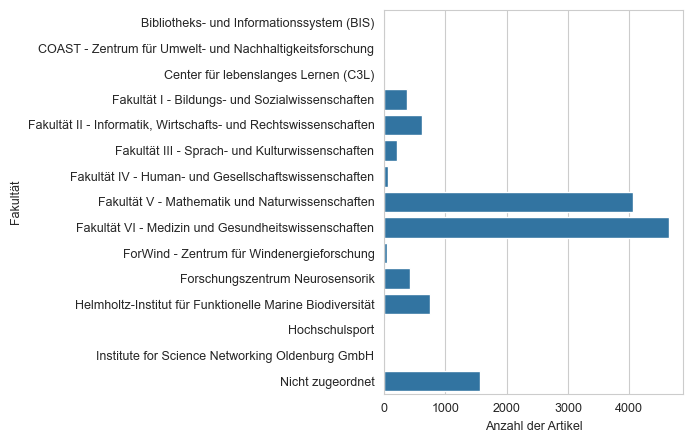

In [800]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [801]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8781936088756934